<a href="https://colab.research.google.com/github/arbutler2003/Pneuomonia-Detection-CNN/blob/main/chest_xray_pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chest X-Ray Pneumonia Detection CNN**
## **Overview**
-TODO

## **Setup**

In [ ]:
# GitHub Credentials
!git config --global user.email "GITHUB_EMAIL"
!git config --global user.name 'arbutler2003'

In [ ]:
import os
from google.colab import userdata, drive

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

drive.mount('/content/drive')

ROOT_PATH = '/content'
DATASET_PATH = os.path.join(ROOT_PATH, 'chest_xray')
GOOGLE_DRIVE_PATH = '/content/drive/MyDrive/AidenB-Capstone-Sp2026'
REPO_PATH = os.path.join(GOOGLE_DRIVE_PATH, 'github')

# Download dataset to the local runtime
if not os.path.exists(DATASET_PATH):
  !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p $ROOT_PATH
  print('Unzipping...')
  !unzip -q $ROOT_PATH/chest-xray-pneumonia.zip -d $ROOT_PATH -x '*__MACOSX*' -x 'chest_xray/chest_xray/*'
  !rm $ROOT_PATH/chest-xray-pneumonia.zip
  print('Download complete.')
else:
  print('Dataset present.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset present.


## **Dataset Restructuring**
This section addresses the dataset's disproportional subsets for training, validation, and testing.

---

The dataset only contains 14 X-ray images in the 'val' subset, which is not nearly enough for validation. The main reason is because a single mistake in validation would cause a substantial drop in performance metrics. To address this, we'll use a script to redistribute the dataset into a 70% training, 15% validation, and 15% testing split. We will also take this opportunity to ensure that each of the three subsets contains a proportional amount (average of this dataset) of 'Pneumonia' and 'Normal' images.


In [ ]:
import os
import glob
import random
import shutil

# To hold the dataset with the new split
WORKING_DIR = '/content/working_dataset'

# Create two lists to hold the pathnames to the two classes of images
pneumonia_image_list = glob.glob(os.path.join(ROOT_PATH, 'chest_xray/*/PNEUMONIA/*'))
normal_image_list = glob.glob(os.path.join(ROOT_PATH, 'chest_xray/*/NORMAL/*'))

# Ensure randomness
random.shuffle(pneumonia_image_list)
random.shuffle(normal_image_list)

pneumonia_image_count = len(pneumonia_image_list)
normal_image_count = len(normal_image_list)

print(f'Pneumonia images: {pneumonia_image_count}')
print(f'Normal images: {normal_image_count}')

# Build the partition points to divide the pathname lists (70% train, 15% val, 15% test)
train_pneumonia_split = int(0.7 * pneumonia_image_count)
val_pneumonia_split = train_pneumonia_split + int(0.15 * pneumonia_image_count)

train_normal_split = int(0.7 * normal_image_count)
val_normal_split = train_normal_split + int(0.15 * normal_image_count)

# Build the new partitions
train_pneumonia = pneumonia_image_list[:train_pneumonia_split]
val_pneumonia = pneumonia_image_list[train_pneumonia_split:val_pneumonia_split]
test_pneumonia = pneumonia_image_list[val_pneumonia_split:]

train_normal = normal_image_list[:train_normal_split]
val_normal = normal_image_list[train_normal_split:val_normal_split]
test_normal = normal_image_list[val_normal_split:]

# Helper function to copy each list of images to it's respective directory
def copy_to_working_directory(file_list, split_type, class_name):
  """
  Copies a list of images to the specified directory. Currently uses shutil.copy()
  to prevent the script from crashing if re-run, however, shutil.move() can be used
  to save space.

  Args:
    file_list: A list of file paths
    split_type: 'train', 'val', or 'test'
    class_name: 'PNEUMONIA' or 'NORMAL'
  """
  destination_dir = os.path.join(WORKING_DIR, split_type, class_name)
  os.makedirs(destination_dir, exist_ok=True)

  for file_path in file_list:
    shutil.copy(file_path, destination_dir)

# Call the helper function to populate the subdirectories
copy_to_working_directory(train_pneumonia, 'train', 'PNEUMONIA')
copy_to_working_directory(val_pneumonia, 'val', 'PNEUMONIA')
copy_to_working_directory(test_pneumonia, 'test', 'PNEUMONIA')

copy_to_working_directory(train_normal, 'train', 'NORMAL')
copy_to_working_directory(val_normal, 'val', 'NORMAL')
copy_to_working_directory(test_normal, 'test', 'NORMAL')

Pneumonia images: 4273
Normal images: 1583


This section displays the class discrency in the dataset and calculates their respective weights.

---



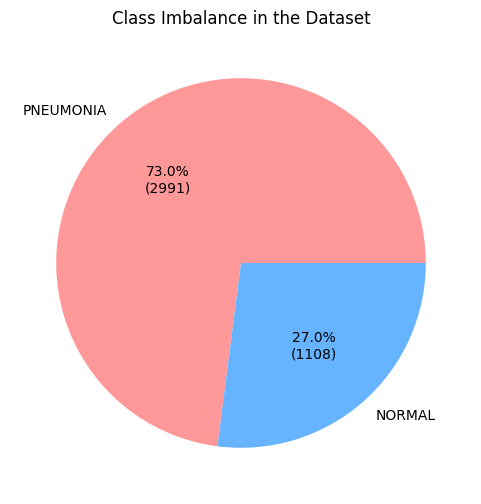

{0: 1.8497292418772564, 1: 0.6852223336676696}


In [ ]:
import matplotlib.pyplot as plot

train_pneumonia_count = len(os.listdir(os.path.join(WORKING_DIR, 'train/PNEUMONIA')))
train_normal_count = len(os.listdir(os.path.join(WORKING_DIR, 'train/NORMAL')))

values = [train_pneumonia_count, train_normal_count]
labels = ['PNEUMONIA', 'NORMAL']

# function to show both percentage and count for the pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

plot.figure(figsize=(6, 6))
plot.pie(
    values,
    labels=labels,
    autopct=make_autopct(values),
    colors=['#ff9999', '#66b3ff']
)
plot.title('Class Imbalance in the Dataset')
plot.show()

# Calculate the class weights
total_count = train_pneumonia_count + train_normal_count

weight_for_normal = (1 / train_normal_count) * (total_count / 2.0)
weight_for_pneumonia = (1 / train_pneumonia_count) * (total_count / 2.0)

class_weight = {0: weight_for_normal, 1: weight_for_pneumonia}
print(class_weight)

## **Preprocessing**
This section prepares the data by defining the directories, image specs, preprocessing the X-rays, and building the batch generators.


---
We use Kera's ResNet50 preprocessing function to prepare the X-ray images. Their function applies two main changes:
* The images' channel order are converted from RGB to BGR.
* The pixel values are zero-centered, which shifts the pixel range from (0, 255) to (-128, 128). During the training of ResNet50, the average value for every pixel in every image was calculated for each color channel. The x-ray pixel values are zero-centered by subtracting the corresponding average.




In [ ]:
import os

# Define dataset subdirectories
train_dir = os.path.join(WORKING_DIR, 'train')
val_dir = os.path.join(WORKING_DIR, 'val')
test_dir = os.path.join(WORKING_DIR, 'test')

# Standard for models trained on ImageNet (i.e., ResNet)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Preprocessing function for ResNet models
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Build generators for each subset
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4099 images belonging to 2 classes.
Found 877 images belonging to 2 classes.
Found 880 images belonging to 2 classes.


## **Preprocessing - Visualization**
This section undoes the ResNet-provided preprocessing function and displays a set of X-rays and their labels for us to view.

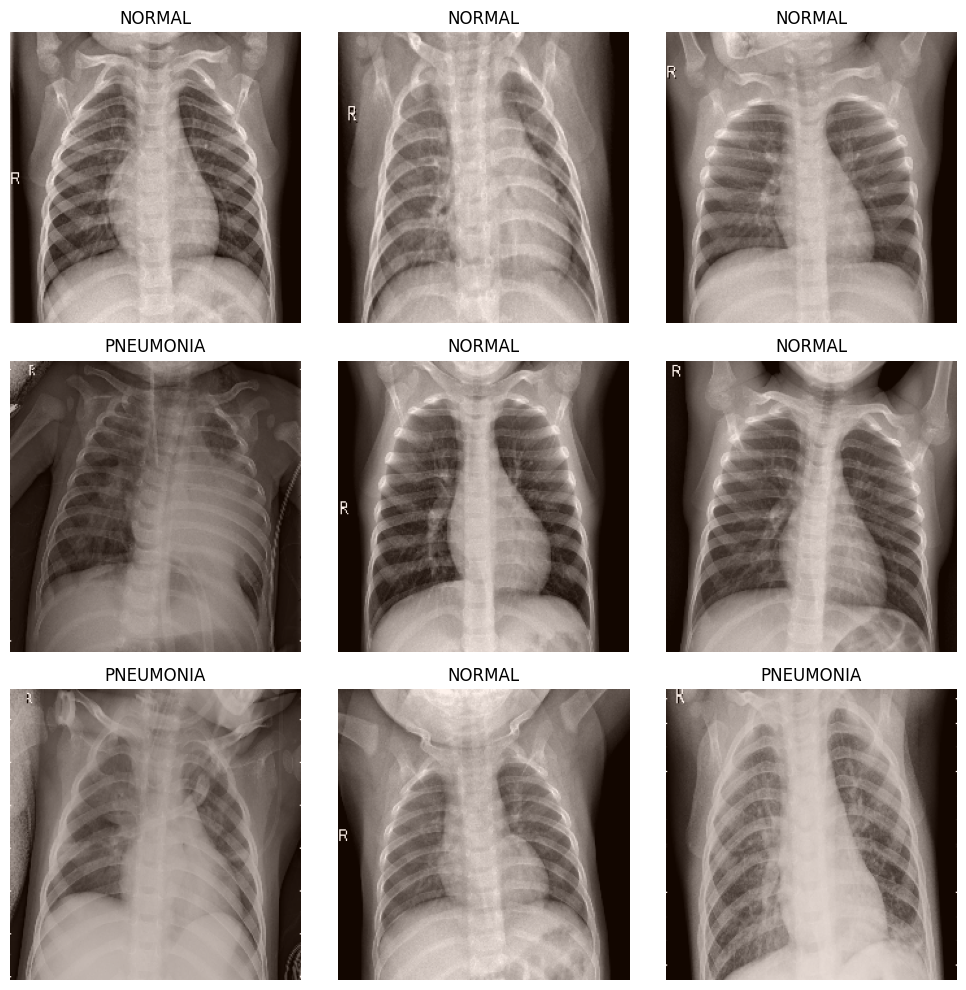

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grab a batch of images and labels
images, labels = next(train_generator)

# Function to undo ResNet preprocessing just for viewing
def deprocess(img):
    img = img.copy()
    img -= img.min()
    img /= img.max()
    return img

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(deprocess(images[i]))
    label_name = "PNEUMONIA" if labels[i] == 1.0 else "NORMAL"
    plt.title(f"{label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Model Creation**
This section instantiates a ResNet50 model for the base layers, and specifies our custom classification head.


---

Here we are using the base layers of the ResNet50 model, which is trained to extract features from images (e.g, shadows or edges). We will extend this model with a top classifying layer to determine which features are relevant, such as shadows from moisture. The complexity going on here is in creating the custom head.
* The ResNet50 (our base model) outputs a block of features with the shape (7, 7, 2048). This can be imagined as a stack of 2,048 different 7x7 images of features that we want to capture as input. To do so, we need to use GlobalAveragePooling2D() to convert ResNet50's 3D vector output into a 1D vector. Keras does this by averaging the value of the pixels within each 49 pixel grid, resulting in a vector containing the 2,048 averages.
* The following dense layer can be thought of as the judge, which evaluates the 2,048 inputs and their corresponding weights. The result is a number (e.g., 5 or -2.7) and we need to scale the range to 0-1 for probability interpretation; to do this, we'll use the sigmoid activation function. After this, we have a single value to reflect the models' determined probability of pneomonia.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.applications.resnet50 import ResNet50

base_model = keras.applications.ResNet50(
    include_top = False, # Exclude ImageNet classification layer
    weights = 'imagenet', # Pre-trained on ImageNet
    input_shape = (224, 224, 3)
)

# Freeze the base layer
base_model.trainable = False

# Create the head of the model
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **Model Compilation**
This section handles the training settings for our custom head.


---

The optimizer adjusts the trainable parameters to better interpret the features that the frozen ResNet50 model serves us.
* A helpful analogy that I saw: The model is a hiker stranded on a jagged mountain on a foggy night trying to reach the bottom of the mountain, which represents minimum loss. The hiker feels the ground 32 times (batch size) to calculate average slope before changing the weights, and the learning rate is how large a step the hiker takes.
* The loss function we're using here is binary cross-entropy which operates on the principle of punishing confident wrongfulness; for example, the model is "punished" harsher for predicting 90% chance of pneumonia in a healthy patient than if it were to predict a 60% chance.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(name='auc')
        ]
)

## **Model Training**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.keras', # File to save the best weights
    monitor='val_loss', # Loss is our primary metric
    mode='min', # We want to minimize loss
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, # Stop if there is no improvement after 3 epochs
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7464 - auc: 0.8283 - loss: 0.5189 - precision: 0.9049 - recall: 0.7283
Epoch 1: val_loss improved from inf to 0.28449, saving model to best_model.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 524ms/step - accuracy: 0.7469 - auc: 0.8290 - loss: 0.5181 - precision: 0.9053 - recall: 0.7288 - val_accuracy: 0.9156 - val_auc: 0.9706 - val_loss: 0.2845 - val_precision: 0.9748 - val_recall: 0.9078
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8927 - auc: 0.9672 - loss: 0.2833 - precision: 0.9674 - recall: 0.8821
Epoch 2: val_loss improved from 0.28449 to 0.22012, saving model to best_model.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 383ms/step - accuracy: 0.8927 - auc: 0.9672 - loss: 0.2832 - precision: 0.9675 - recall: 0.8821 - val_accuracy: 0.9316 - val_auc: 0.9806 - val_loss: 0.2201 - val_precision: 0.9739 - val_recall: 0.9312
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.9180 - auc: 0.9791 -

Visualize

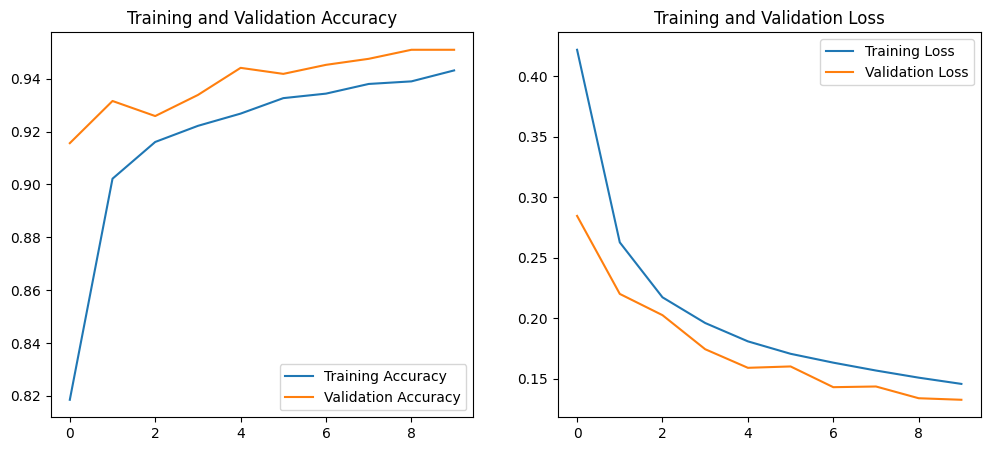

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)

Test

In [ ]:
# Load the best weights
model.load_weights('best_model.keras')

# Run evaluation
print("Evaluating on Test Set...")
test_results = model.evaluate(test_generator, verbose=1)

# In Keras 3, metrics are often bundled. Let's map them by their specific display names.
# test_results[0] is 'loss'
# test_results[1] is 'accuracy', [2] is 'recall', etc.
print("-" * 30)
print(f"Test Accuracy:  {test_results[1]:.2%}")
print(f"Test Recall:    {test_results[2]:.2%}")
print(f"Test Precision: {test_results[3]:.2%}")
print(f"Test AUC:       {test_results[4]:.4f}")
print("-" * 30)

Evaluating on Test Set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.9510 - auc: 0.7473 - loss: 0.1519 - precision: 0.7174 - recall: 0.7050
------------------------------
Test Accuracy:  94.09%
Test Recall:    93.30%
Test Precision: 98.52%
Test AUC:       0.9824
------------------------------


Save

In [ ]:
import shutil

# Copy the best model to your Capstone folder on Drive
shutil.copy('best_model.keras', GOOGLE_DRIVE_PATH)

'/content/drive/MyDrive/AidenB-Capstone-Sp2026/best_model.keras'